In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
from alpsplot.figure import Figure
from alpsplot.colormap import tab20c_color, ting_color

In [45]:
ting_color

{'red': '#DB3236',
 'red_carrot': '#E34638',
 'red_deep': '#C44C3F',
 'purple': '#593982',
 'green': '#429E46',
 'blue': '#6876AB',
 'blue_light': '#4885ED',
 'blue_grey': '#7396AE',
 'yellow': '#F7B52B',
 'yellow_deep': '#E7AD4C',
 'grey': '#989898'}

In [46]:
'''
dic["model_name"] = dic2
dic2["group_name"] = [1.0,1.0] # FSR ICR
'''

'\ndic["model_name"] = dic2\ndic2["group_name"] = [1.0,1.0] # FSR ICR\n'

In [47]:
# total_dic = {}
# total_dic["r1llama"] = {}
# total_dic["r1llama"]["MathLogic"] = [0.136,0.091]
# total_dic["r1llama"]["SciEng"] = [0.276,0.161]
# total_dic["r1llama"]["Computing"] = [0.236,0.185]
# total_dic["r1llama"]["LifeSci"] = [0.194,0.326]
# total_dic["r1llama"]["Health"] = [0.160,0.538]
# total_dic["r1llama"]["BusinessEcon"] = [0.298,0.358]
# total_dic["r1llama"]["Society"] = [0.317,0.120]
# total_dic["r1llama"]["Humanities"] = [0.226,0.364]

# total_dic["r1qwen"] = {}
# total_dic["r1qwen"]["MathLogic"] = [0.073, 0.068]
# total_dic["r1qwen"]["SciEng"] = [0.096,0.180]
# total_dic["r1qwen"]["Computing"] = [0.070, 0.035]
# total_dic["r1qwen"]["LifeSci"] = []
# total_dic["r1qwen"]["Health"] = []
# total_dic["r1qwen"]["BusinessEcon"] = []
# total_dic["r1qwen"]["Society"] = []
# total_dic["r1qwen"]["Humanities"] = []

# total_dic["r1qwen3"] = {}
# total_dic["r1qwen3"]["MathLogic"] = [0.011, 0.033]
# total_dic["r1qwen3"]["SciEng"] = [0.008,0.216]
# total_dic["r1qwen3"]["Computing"] = [0.019, 0.248]
# total_dic["r1qwen3"]["LifeSci"] = []
# total_dic["r1qwen3"]["Health"] = []
# total_dic["r1qwen3"]["BusinessEcon"] = []
# total_dic["r1qwen3"]["Society"] = []
# total_dic["r1qwen3"]["Humanities"] = []


# total_dic["phi"] = {}
# total_dic["phi"]["MathLogic"] = [0.008,0.093]
# total_dic["phi"]["SciEng"] = [0.005, 0.094]
# total_dic["phi"]["Computing"] = [0.018,0.060]
# total_dic["phi"]["LifeSci"] = []
# total_dic["phi"]["Health"] = []
# total_dic["phi"]["BusinessEcon"] = []
# total_dic["phi"]["Society"] = []
# total_dic["phi"]["Humanities"] = []


# total_dic["qwen3"] = {}
# total_dic["qwen3"]["MathLogic"] = [0.003, 0.020]
# total_dic["qwen3"]["SciEng"] = [0.024,0.089]
# total_dic["qwen3"]["Computing"] = [0.002, 0.094]
# total_dic["qwen3"]["LifeSci"] = []
# total_dic["qwen3"]["Health"] = []
# total_dic["qwen3"]["BusinessEcon"] = []
# total_dic["qwen3"]["Society"] = []
# total_dic["qwen3"]["Humanities"] = []

In [48]:
total_dic = {}
total_dic["r1llama"] = {}
total_dic["r1llama"]["MathLogic"] = [0.076,0.071]
total_dic["r1llama"]["SciEng"] = [0.176,0.161]
total_dic["r1llama"]["Computing"] = [0.186,0.185]
total_dic["r1llama"]["LifeSci"] = [0.194,0.226]
total_dic["r1llama"]["Health"] = [0.160,0.238]
total_dic["r1llama"]["BusinessEcon"] = [0.258,0.258]
total_dic["r1llama"]["Society"] = [0.287,0.180]
total_dic["r1llama"]["Humanities"] = [0.226,0.264]

total_dic["r1llama_rl"] = {}
total_dic["r1llama_rl"]["MathLogic"] = [0.058, 0.030]
total_dic["r1llama_rl"]["SciEng"] = [0.153, 0.115]
total_dic["r1llama_rl"]["Computing"] = [0.178, 0.132]
total_dic["r1llama_rl"]["LifeSci"] = [0.173, 0.176]
total_dic["r1llama_rl"]["Health"] = [0.139, 0.187]
total_dic["r1llama_rl"]["BusinessEcon"] = [0.240, 0.194]
total_dic["r1llama_rl"]["Society"] = [0.262, 0.140]
total_dic["r1llama_rl"]["Humanities"] = [0.204, 0.201]


total_dic["r1qwen"] = {}
total_dic["r1qwen"]["MathLogic"] = [0.033, 0.048]
total_dic["r1qwen"]["SciEng"] = [0.096,0.110]
total_dic["r1qwen"]["Computing"] = [0.120, 0.095]
total_dic["r1qwen"]["LifeSci"] = [0.112,0.086]
total_dic["r1qwen"]["Health"] = [0.120,0.088]
total_dic["r1qwen"]["BusinessEcon"] = [0.158,0.128]
total_dic["r1qwen"]["Society"] = [0.137,0.110]
total_dic["r1qwen"]["Humanities"] = [0.136,0.134]

total_dic["r1qwen_rl"] = {}
total_dic["r1qwen_rl"]["MathLogic"] = [0.023, 0.026]    
total_dic["r1qwen_rl"]["SciEng"] = [0.085, 0.077]        
total_dic["r1qwen_rl"]["Computing"] = [0.115, 0.070]    
total_dic["r1qwen_rl"]["LifeSci"] = [0.104, 0.062]       
total_dic["r1qwen_rl"]["Health"] = [0.114, 0.068]       
total_dic["r1qwen_rl"]["BusinessEcon"] = [0.148, 0.093]  
total_dic["r1qwen_rl"]["Society"] = [0.127, 0.079]      
total_dic["r1qwen_rl"]["Humanities"] = [0.126, 0.101]    


total_dic["r1qwen1b"] = {}
total_dic["r1qwen1b"]["MathLogic"] = [0.053, 0.044]
total_dic["r1qwen1b"]["SciEng"] = [0.197,0.026]
total_dic["r1qwen1b"]["Computing"] = [0.193, 0.042]
total_dic["r1qwen1b"]["LifeSci"] = [0.212,0.066]
total_dic["r1qwen1b"]["Health"] = [0.210,0.068]
total_dic["r1qwen1b"]["BusinessEcon"] = [0.238,0.102]
total_dic["r1qwen1b"]["Society"] = [0.207,0.100]
total_dic["r1qwen1b"]["Humanities"] = [0.186,0.084]

total_dic["r1qwen14b"] = {}
total_dic["r1qwen14b"]["MathLogic"] = [0.046, 0.146]
total_dic["r1qwen14b"]["SciEng"] = [0.020,0.223]
total_dic["r1qwen14b"]["Computing"] = [0.067, 0.261]
total_dic["r1qwen14b"]["LifeSci"] = [0.062,0.086]
total_dic["r1qwen14b"]["Health"] = [0.061,0.088]
total_dic["r1qwen14b"]["BusinessEcon"] = [0.078,0.128]
total_dic["r1qwen14b"]["Society"] = [0.067,0.110]
total_dic["r1qwen14b"]["Humanities"] = [0.066,0.134]

total_dic["r1qwen32b"] = {}
total_dic["r1qwen32b"]["MathLogic"] = [0.017, 0.096]
total_dic["r1qwen32b"]["SciEng"] = [0.013,0.179]
total_dic["r1qwen32b"]["Computing"] = [0.028, 0.189]
total_dic["r1qwen32b"]["LifeSci"] = [0.021,0.059]
total_dic["r1qwen32b"]["Health"] = [0.025,0.049]
total_dic["r1qwen32b"]["BusinessEcon"] = [0.031,0.119]
total_dic["r1qwen32b"]["Society"] = [0.032,0.089]
total_dic["r1qwen32b"]["Humanities"] = [0.030,0.079]

total_dic["r1qwen3"] = {}
total_dic["r1qwen3"]["MathLogic"] = [0.011, 0.033]
total_dic["r1qwen3"]["SciEng"] = [0.038,0.166]
total_dic["r1qwen3"]["Computing"] = [0.049, 0.148]
total_dic["r1qwen3"]["LifeSci"] = [0.051, 0.158]
total_dic["r1qwen3"]["Health"] = [0.058, 0.159]
total_dic["r1qwen3"]["BusinessEcon"] = [0.051, 0.198]
total_dic["r1qwen3"]["Society"] = [0.049, 0.113]
total_dic["r1qwen3"]["Humanities"] = [0.048, 0.143]


total_dic["phi"] = {}
total_dic["phi"]["MathLogic"] = [0.008,0.023]
total_dic["phi"]["SciEng"] = [0.015, 0.034]
total_dic["phi"]["Computing"] = [0.018,0.046]
total_dic["phi"]["LifeSci"] = [0.028,0.034]
total_dic["phi"]["Health"] = [0.032,0.043]
total_dic["phi"]["BusinessEcon"] = [0.038,0.071]
total_dic["phi"]["Society"] = [0.022,0.032]
total_dic["phi"]["Humanities"] = [0.028,0.041]

total_dic["phibig"] = {}
total_dic["phibig"]["MathLogic"] = [0.004,0.033]
total_dic["phibig"]["SciEng"] = [0.010, 0.044]
total_dic["phibig"]["Computing"] = [0.011,0.052]
total_dic["phibig"]["LifeSci"] = [0.014,0.041]
total_dic["phibig"]["Health"] = [0.019,0.041]
total_dic["phibig"]["BusinessEcon"] = [0.019,0.069]
total_dic["phibig"]["Society"] = [0.017,0.048]
total_dic["phibig"]["Humanities"] = [0.013,0.039]


total_dic["qwen3"] = {}
total_dic["qwen3"]["MathLogic"] = [0.003, 0.020]
total_dic["qwen3"]["SciEng"] = [0.024,0.089]
total_dic["qwen3"]["Computing"] = [0.012, 0.094]
total_dic["qwen3"]["LifeSci"] = [0.002, 0.114]
total_dic["qwen3"]["Health"] = [0.017, 0.134]
total_dic["qwen3"]["BusinessEcon"] = [0.021, 0.184]
total_dic["qwen3"]["Society"] = [0.019, 0.164]
total_dic["qwen3"]["Humanities"] = [0.013, 0.091]


total_dic["qwen34b"] = {}
total_dic["qwen34b"]["MathLogic"] = [0.008, 0.021]
total_dic["qwen34b"]["SciEng"] = [0.032,0.083]
total_dic["qwen34b"]["Computing"] = [0.036, 0.101]
total_dic["qwen34b"]["LifeSci"] = [0.008, 0.118]
total_dic["qwen34b"]["Health"] = [0.020, 0.121]
total_dic["qwen34b"]["BusinessEcon"] = [0.030, 0.194]
total_dic["qwen34b"]["Society"] = [0.018, 0.165]
total_dic["qwen34b"]["Humanities"] = [0.017, 0.103]

total_dic["qwen31b"] = {}
total_dic["qwen31b"]["MathLogic"] = [0.014, 0.021]
total_dic["qwen31b"]["SciEng"] = [0.052,0.150]
total_dic["qwen31b"]["Computing"] = [0.056, 0.132]
total_dic["qwen31b"]["LifeSci"] = [0.012, 0.134]
total_dic["qwen31b"]["Health"] = [0.027, 0.136]
total_dic["qwen31b"]["BusinessEcon"] = [0.032, 0.214]
total_dic["qwen31b"]["Society"] = [0.030, 0.137]
total_dic["qwen31b"]["Humanities"] = [0.021, 0.131]


total_dic["qwen314b"] = {}
total_dic["qwen314b"]["MathLogic"] = [0.002, 0.076]
total_dic["qwen314b"]["SciEng"] = [0.014,0.189]
total_dic["qwen314b"]["Computing"] = [0.008, 0.184]
total_dic["qwen314b"]["LifeSci"] = [0.002, 0.154]
total_dic["qwen314b"]["Health"] = [0.009, 0.154]
total_dic["qwen314b"]["BusinessEcon"] = [0.015, 0.184]
total_dic["qwen314b"]["Society"] = [0.010, 0.164]
total_dic["qwen314b"]["Humanities"] = [0.006, 0.166]

total_dic["qwen332b"] = {}
total_dic["qwen332b"]["MathLogic"] = [0.002, 0.056]
total_dic["qwen332b"]["SciEng"] = [0.008,0.097]
total_dic["qwen332b"]["Computing"] = [0.005, 0.099]
total_dic["qwen332b"]["LifeSci"] = [0.002, 0.149]
total_dic["qwen332b"]["Health"] = [0.004, 0.139]
total_dic["qwen332b"]["BusinessEcon"] = [0.010, 0.199]
total_dic["qwen332b"]["Society"] = [0.002, 0.179]
total_dic["qwen332b"]["Humanities"] = [0.004, 0.139]

model_name_list = ["r1llama", "r1qwen", "r1qwen1b", "r1qwen14b", "r1qwen32b", "r1qwen3", "phi", "phibig", "qwen3", "qwen31b", "qwen34b", "qwen314b", "qwen332b"]
group_name_list = ['MathLogic', 'SciEng', 'Computing', 'LifeSci', 'Health', 'BusinessEcon', 'Society', 'Humanities']

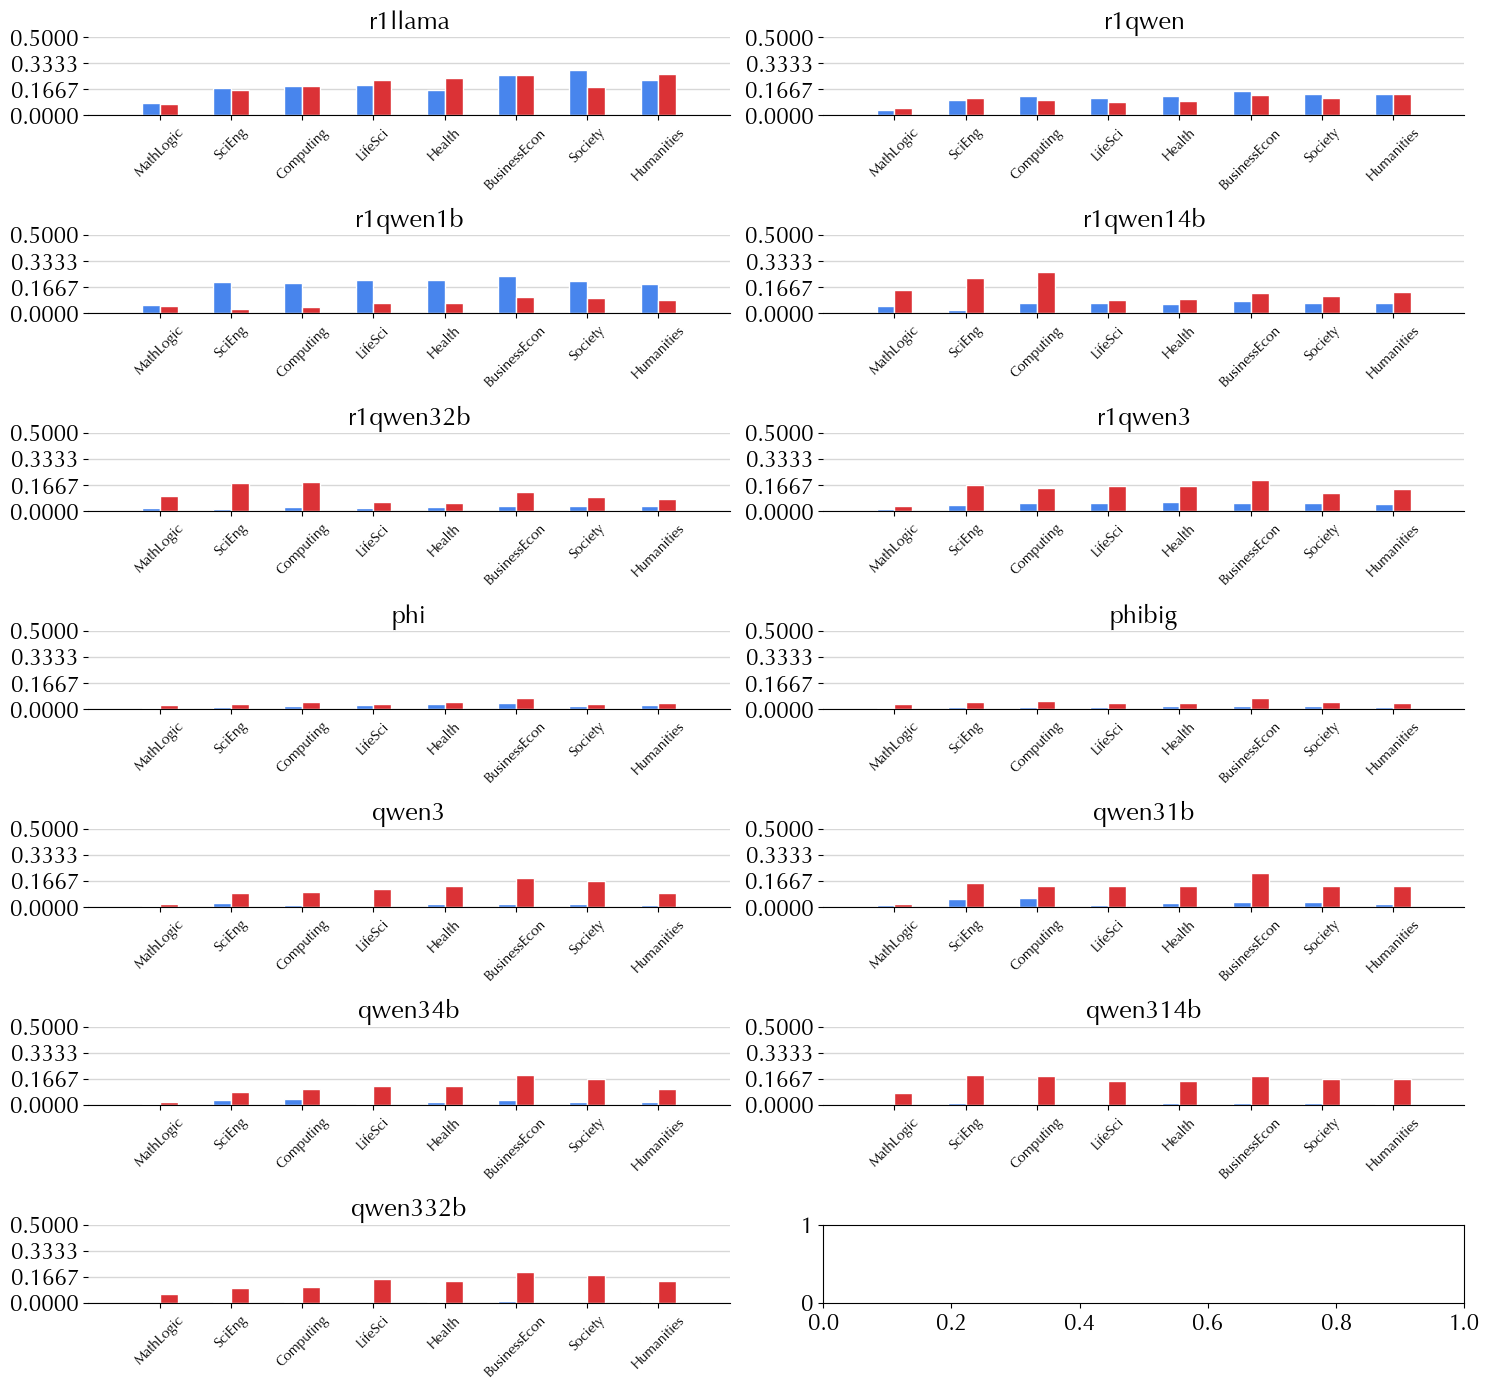

In [49]:
fig_all, axes = plt.subplots(7, 2, figsize=(15, 14))
fig_all.subplots_adjust(wspace=0.4, hspace=1) 
count = 0
width = 0.25
x = np.arange(len(group_name_list))
x1 = x - width/2
x2 = x + width/2
for i in range(7):
    for j in range(2):
        if count >=13:
            break
        model_name = model_name_list[count]
        fig = Figure(name = f'{model_name}', figsize=(3, 3), ax=axes[i, j])
        fig.set_axis_lim("x", piece = len(group_name_list) - 1, lim = (0, len(group_name_list) - 1), labels = group_name_list, margin=(1,1), fontdict = {'fontsize': 10}, rotation = 45)
        fig.set_axis_lim("y", lim = (0, 0.5), piece = 3)
        x = np.arange(len(group_name_list))
        FSR = []
        ICR = []
        for group in group_name_list:
            temp_list = total_dic[model_name][group]
            if len(temp_list) != 2:
                temp_list = [0, 0]
            FSR.append(temp_list[0])
            ICR.append(temp_list[1])
            total_dic[model_name]["FSR"] = sum(FSR) / len(FSR)
            total_dic[model_name]["ICR"] = sum(ICR) / len(ICR)
        bar1 = fig.bar(x1, FSR, width = width, label='FSR', color = ting_color["blue_light"], align= 'center')
        bar2 = fig.bar(x2, ICR, width = width, label='ICR', color = ting_color["red"], align= 'center')
        fig.set_title(model_name)
        # fig.ax.tick_params(axis = 'x', rotation = 45)
        count += 1
plt.tight_layout()
plt.show()

In [60]:
# # distill model vs non-distill model
# distillmodel_name_list = ['r1llama', 'r1qwen', 'r1qwen3', 'r1qwen1b', 'r1qwen14b', 'r1qwen32b']
# non_distill_model_name_list = ["phi", "qwen3", "phibig", "qwen31b", "qwen34b", "qwen314b", "qwen332b"]

# distill_FSR_list = np.array([total_dic[model_name]["FSR"] for model_name in distillmodel_name_list])
# distill_ICR_list = np.array([total_dic[model_name]["ICR"] for model_name in distillmodel_name_list])
# non_distill_FSR_list = np.array([total_dic[model_name]["FSR"] for model_name in non_distill_model_name_list])
# non_distill_ICR_list = np.array([total_dic[model_name]["ICR"] for model_name in non_distill_model_name_list])
# fig = Figure(name = 'distill_vs_non_distill', figsize=(5, 5))
# # fig.set_axis_lim("x", piece = len(distillmodel_name_list) - 1, lim = (0, len(distillmodel_name_list) - 1), labels = distillmodel_name_list, margin=(1,1), fontdict = {'fontsize': 10}, rotation = 45)
# # fig.set_axis_lim("y", lim = (0, 0.5), piece = 3)
# width = 0.25
# x = np.arange(2)
# x1 = x - width/2
# x2 = x + width/2
# fig.bar(x1, [np.mean(distill_FSR_list), np.mean(non_distill_FSR_list)], yerr = [np.std(distill_FSR_list), np.std(non_distill_FSR_list)], width = width, label='FSR', color = ting_color["blue_light"], align= 'center')
# fig.bar(x2, [np.mean(distill_ICR_list), np.mean(non_distill_ICR_list)], yerr = [np.std(distill_ICR_list), np.std(non_distill_ICR_list)], width = width, label='ICR', color = ting_color["red"], align= 'center')
# fig.set_legend()
# # fig.save(dpi=300)
# # ******分开来 overall error rate consistnet/inconsistent比例

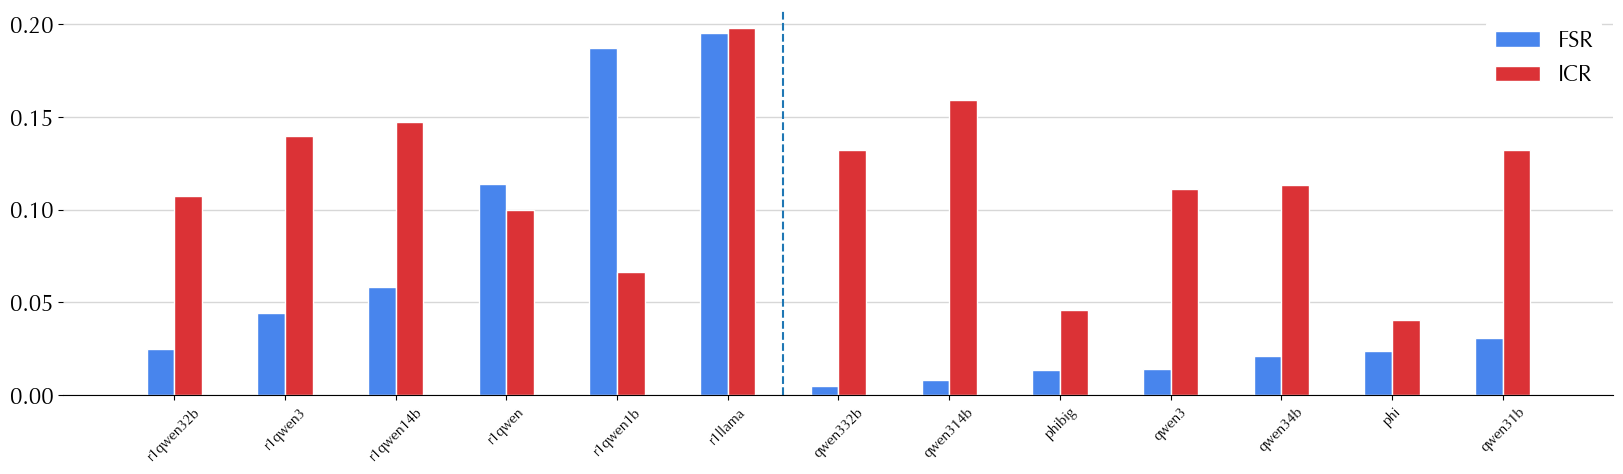

In [51]:
# distill model vs non-distill model
distillmodel_name_list = ['r1llama', 'r1qwen', 'r1qwen3', 'r1qwen1b', 'r1qwen14b', 'r1qwen32b']
non_distill_model_name_list = ["phi", "qwen3", "phibig", "qwen31b", "qwen34b", "qwen314b", "qwen332b"]

distill_FSR_list = np.array([total_dic[model_name]["FSR"] for model_name in distillmodel_name_list])
distill_ICR_list = np.array([total_dic[model_name]["ICR"] for model_name in distillmodel_name_list])

sort_index1 = np.argsort(distill_FSR_list)
sort_index2 = np.argsort(non_distill_FSR_list)

distillmodel_name_list = [distillmodel_name_list[i] for i in sort_index1]
non_distill_model_name_list = [non_distill_model_name_list[i] for i in sort_index2]

distill_FSR_list = np.array([total_dic[model_name]["FSR"] for model_name in distillmodel_name_list])
distill_ICR_list = np.array([total_dic[model_name]["ICR"] for model_name in distillmodel_name_list])
non_distill_FSR_list = np.array([total_dic[model_name]["FSR"] for model_name in non_distill_model_name_list])
non_distill_ICR_list = np.array([total_dic[model_name]["ICR"] for model_name in non_distill_model_name_list])
fig = Figure(name = 'distill_vs_non_distill', figsize=(20, 5))

# fig.set_axis_lim("y", lim = (0, 0.5), piece = 3)
FSR_list = np.concatenate([distill_FSR_list, non_distill_FSR_list])
ICR_list = np.concatenate([distill_ICR_list, non_distill_ICR_list])

width = 0.25
x = np.arange(len(FSR_list))
x1 = x - width/2
x2 = x + width/2
fig.set_axis_lim("x", piece = len(FSR_list) - 1, lim = (0, len(FSR_list) - 1), labels = distillmodel_name_list + non_distill_model_name_list, margin=(1,1), fontdict = {'fontsize': 10}, rotation = 45)
fig.bar(x1, FSR_list, width = width, label='FSR', color = ting_color["blue_light"], align= 'center')
fig.bar(x2, ICR_list, width = width, label='ICR', color = ting_color["red"], align= 'center')
fig.set_legend()
fig.ax.axvline(x = len(distillmodel_name_list) - 2 * width, linestyle = '--')
# fig.save(dpi=300)
# ******分开来 overall error rate consistnet/inconsistent比例

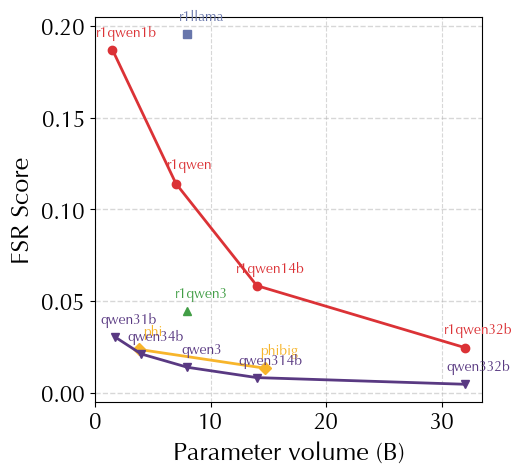

In [66]:
# distill model vs non-distill model

fig = Figure(name = 'model_size_FSR', figsize=(5, 5))
fig.ax.grid(True, linestyle = '--', alpha = 0.5)
# 添加四周的框线
fig.ax.spines['top'].set_visible(True)
fig.ax.spines['right'].set_visible(True)
fig.ax.spines['bottom'].set_visible(True)
fig.ax.spines['left'].set_visible(True)

# r1qwen
model_size_r1qwen = [1.5,7,14, 32]
model_name_r1qwen = ["r1qwen1b", "r1qwen" , "r1qwen14b", "r1qwen32b"]
color1 = ting_color["red"]
model_score_r1qwen = [total_dic[model_name]["FSR"] for model_name in model_name_r1qwen]
fig.lineplot(model_size_r1qwen, model_score_r1qwen, marker = "o", label='r1qwen', color = color1, markerfacecolor = color1)
for i, (x, y, name) in enumerate(zip(model_size_r1qwen, model_score_r1qwen, model_name_r1qwen)):
    fig.ax.annotate(name, (x, y), textcoords="offset points", xytext=(10,10), ha='center', color = color1)

# r1llama
model_size_r1llama = [8]
model_name_r1llama = ["r1llama"]
color2 = ting_color["blue"]
model_score_r1llama = [total_dic[model_name]["FSR"] for model_name in model_name_r1llama]
fig.lineplot(model_size_r1llama, model_score_r1llama, marker = "s", label='r1llama', color = color2, markerfacecolor=color2)
for i, (x, y, name) in enumerate(zip(model_size_r1llama, model_score_r1llama, model_name_r1llama)):
    fig.ax.annotate(name, (x, y), textcoords="offset points", xytext=(10,10), ha='center', color = color2)

# r1qwen3
model_size_r1qwen3 = [8]
model_name_r1qwen3 = ["r1qwen3"]
color3 = ting_color["green"]
model_score_r1qwen3 = [total_dic[model_name]["FSR"] for model_name in model_name_r1qwen3]
fig.lineplot(model_size_r1qwen3, model_score_r1qwen3, marker = "^", label='r1qwen3', color = color3, markerfacecolor=color3)
for i, (x, y, name) in enumerate(zip(model_size_r1qwen3, model_score_r1qwen3, model_name_r1qwen3)):
    fig.ax.annotate(name, (x, y), textcoords="offset points", xytext=(10,10), ha='center', color = color3)

# phi
model_size_phi = [3.8, 14.7]
model_name_phi = ["phi", "phibig"]
color4 = ting_color["yellow"]
model_score_phi = [total_dic[model_name]["FSR"] for model_name in model_name_phi]
fig.lineplot(model_size_phi, model_score_phi, marker = "D", label='phi', color = color4, markerfacecolor=color4)
for i, (x, y, name) in enumerate(zip(model_size_phi, model_score_phi, model_name_phi)):
    fig.ax.annotate(name, (x, y), textcoords="offset points", xytext=(10,10), ha='center', color = color4)

# qwen3
model_size_qwen3 = [1.7,4, 8, 14, 32]
model_name_qwen3 = ["qwen31b", "qwen34b", "qwen3", "qwen314b", "qwen332b"]
color5 = ting_color["purple"]
model_score_qwen3 = [total_dic[model_name]["FSR"] for model_name in model_name_qwen3]
fig.lineplot(model_size_qwen3, model_score_qwen3, marker = "v", label='qwen3', color = color5, markerfacecolor=color5)
for i, (x, y, name) in enumerate(zip(model_size_qwen3, model_score_qwen3, model_name_qwen3)):
    fig.ax.annotate(name, (x, y), textcoords="offset points", xytext=(10,10), ha='center', color = color5)

# fig.set_legend()

# fig.ax.set_xscale('log')
fig.set_axis_label(axis = "x", text = "Parameter volume (B)")
fig.set_axis_label(axis = "y", text = "FSR Score")

plt.show()

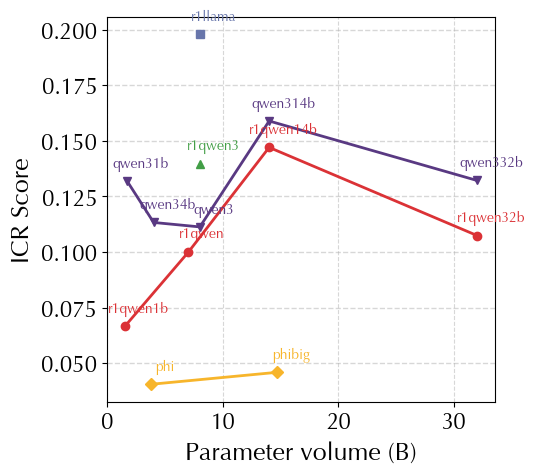

In [67]:
fig = Figure(name = 'model_size_ICR', figsize=(5, 5))
fig.ax.grid(True, linestyle = '--', alpha = 0.5)
# 添加四周的框线
fig.ax.spines['top'].set_visible(True)
fig.ax.spines['right'].set_visible(True)
fig.ax.spines['bottom'].set_visible(True)
fig.ax.spines['left'].set_visible(True)

# r1qwen
model_size_r1qwen = [1.5,7,14, 32]
model_name_r1qwen = ["r1qwen1b", "r1qwen" , "r1qwen14b", "r1qwen32b"]
color1 = ting_color["red"]
model_score_r1qwen = [total_dic[model_name]["ICR"] for model_name in model_name_r1qwen]
fig.lineplot(model_size_r1qwen, model_score_r1qwen, marker = "o", label='r1qwen', color = color1, markerfacecolor = color1)
for i, (x, y, name) in enumerate(zip(model_size_r1qwen, model_score_r1qwen, model_name_r1qwen)):
    fig.ax.annotate(name, (x, y), textcoords="offset points", xytext=(10,10), ha='center', color = color1)

# r1llama
model_size_r1llama = [8]
model_name_r1llama = ["r1llama"]
color2 = ting_color["blue"]
model_score_r1llama = [total_dic[model_name]["ICR"] for model_name in model_name_r1llama]
fig.lineplot(model_size_r1llama, model_score_r1llama, marker = "s", label='r1llama', color = color2, markerfacecolor=color2)
for i, (x, y, name) in enumerate(zip(model_size_r1llama, model_score_r1llama, model_name_r1llama)):
    fig.ax.annotate(name, (x, y), textcoords="offset points", xytext=(10,10), ha='center', color = color2)

# r1qwen3
model_size_r1qwen3 = [8]
model_name_r1qwen3 = ["r1qwen3"]
color3 = ting_color["green"]
model_score_r1qwen3 = [total_dic[model_name]["ICR"] for model_name in model_name_r1qwen3]
fig.lineplot(model_size_r1qwen3, model_score_r1qwen3, marker = "^", label='r1qwen3', color = color3, markerfacecolor=color3)
for i, (x, y, name) in enumerate(zip(model_size_r1qwen3, model_score_r1qwen3, model_name_r1qwen3)):
    fig.ax.annotate(name, (x, y), textcoords="offset points", xytext=(10,10), ha='center', color = color3)

# phi
model_size_phi = [3.8, 14.7]
model_name_phi = ["phi", "phibig"]
color4 = ting_color["yellow"]
model_score_phi = [total_dic[model_name]["ICR"] for model_name in model_name_phi]
fig.lineplot(model_size_phi, model_score_phi, marker = "D", label='phi', color = color4, markerfacecolor=color4)
for i, (x, y, name) in enumerate(zip(model_size_phi, model_score_phi, model_name_phi)):
    fig.ax.annotate(name, (x, y), textcoords="offset points", xytext=(10,10), ha='center', color = color4)

# qwen3
model_size_qwen3 = [1.7,4, 8, 14, 32]
model_name_qwen3 = ["qwen31b", "qwen34b", "qwen3", "qwen314b", "qwen332b"]
color5 = ting_color["purple"]
model_score_qwen3 = [total_dic[model_name]["ICR"] for model_name in model_name_qwen3]
fig.lineplot(model_size_qwen3, model_score_qwen3, marker = "v", label='qwen3', color = color5, markerfacecolor=color5)
for i, (x, y, name) in enumerate(zip(model_size_qwen3, model_score_qwen3, model_name_qwen3)):
    fig.ax.annotate(name, (x, y), textcoords="offset points", xytext=(10,10), ha='center', color = color5)

fig.set_axis_label(axis = "x", text = "Parameter volume (B)")
fig.set_axis_label(axis = "y", text = "ICR Score")

# fig.set_legend()

# log x axis
# fig.ax.set_xscale('log')

plt.show()

In [54]:
# # distill model vs non-distill model

# fig = Figure(name = 'model_size_FSR', figsize=(5, 5))

# # r1qwen
# model_size_r1qwen = [1.5,7,14]
# model_name_r1qwen = ["r1qwen1b", "r1qwen" , "r1qwen14b"]
# # model_score_r1qwen = [total_dic[model_name]["FSR"] + total_dic[model_name]["ICR"] for model_name in model_name_r1qwen]
# model_score_r1qwen = [total_dic[model_name]["FSR"] for model_name in model_name_r1qwen]
# fig.lineplot(model_size_r1qwen, model_score_r1qwen, marker = "o", label='r1qwen')


# # r1llama
# model_size_r1llama = [8]
# model_name_r1llama = ["r1llama"]
# model_score_r1llama = [total_dic[model_name]["FSR"] + total_dic[model_name]["ICR"] for model_name in model_name_r1llama]
# fig.lineplot(model_size_r1llama, model_score_r1llama, marker = "o", label='r1llama')

# # r1qwen3
# model_size_r1qwen3 = [8]
# model_name_r1qwen3 = ["r1qwen3"]
# model_score_r1qwen3 = [total_dic[model_name]["FSR"] + total_dic[model_name]["ICR"] for model_name in model_name_r1qwen3]
# fig.lineplot(model_size_r1qwen3, model_score_r1qwen3, marker = "o", label='r1qwen3')

# # phi
# model_size_phi = [3]
# model_name_phi = ["phi"]
# model_score_phi = [total_dic[model_name]["FSR"] + total_dic[model_name]["ICR"] for model_name in model_name_phi]
# fig.lineplot(model_size_phi, model_score_phi, marker = "o", label='phi')

# # qwen3
# model_size_qwen3 = [8]
# model_name_qwen3 = ["qwen3"]
# model_score_qwen3 = [total_dic[model_name]["FSR"] + total_dic[model_name]["ICR"] for model_name in model_name_qwen3]
# fig.lineplot(model_size_qwen3, model_score_qwen3, marker = "o", label='qwen3')

# fig.set_legend()

# plt.show()

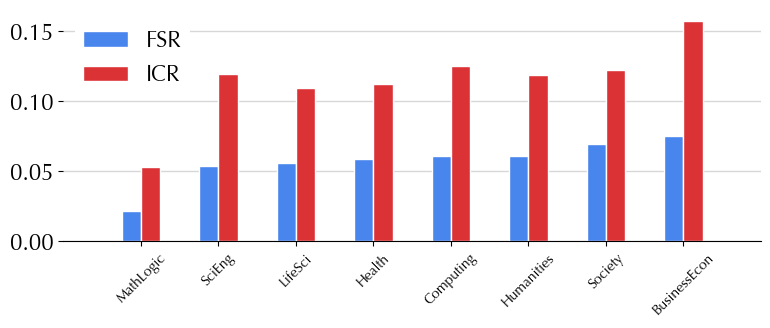

In [59]:
group_FSR_list = []
group_FSR_list_std = []
group_ICR_list = []
group_ICR_list_std = []
for group in group_name_list:
    temp_list_FSR = []
    temp_list_ICR = []
    for model_name in model_name_list:
        try:
            temp_list_FSR.append(total_dic[model_name][group][0])
            temp_list_ICR.append(total_dic[model_name][group][1])
        except:
            temp_list_FSR.append(0)
            temp_list_ICR.append(0)
    group_FSR_list.append(np.mean(temp_list_FSR))
    group_FSR_list_std.append(np.std(temp_list_FSR))
    group_ICR_list.append(np.mean(temp_list_ICR))
    group_ICR_list_std.append(np.std(temp_list_ICR))

# 按FSR排序所有数据
combined_data = list(zip(group_name_list, group_FSR_list, group_FSR_list_std, group_ICR_list, group_ICR_list_std))
# 按FSR值降序排序（索引1是FSR值）
sorted_data = sorted(combined_data, key=lambda x: x[1])

# 解压排序后的数据
sorted_group_names, sorted_FSR_list, sorted_FSR_std, sorted_ICR_list, sorted_ICR_std = zip(*sorted_data)

fig = Figure(name = 'group_FSR_ICR', figsize=(9, 3))
width = 0.25
x = np.arange(len(sorted_group_names))
x1 = x - width/2
x2 = x + width/2
fig.set_axis_lim("x", piece = len(sorted_group_names) - 1, lim = (0, len(sorted_group_names) - 1), labels = sorted_group_names, margin=(1,1), fontdict = {'fontsize': 10}, rotation = 45)
fig.bar(x1, sorted_FSR_list, width = width, label='FSR', color = ting_color["blue_light"], align= 'center')
fig.bar(x2, sorted_ICR_list, width = width, label='ICR', color = ting_color["red"], align= 'center')
fig.set_legend()

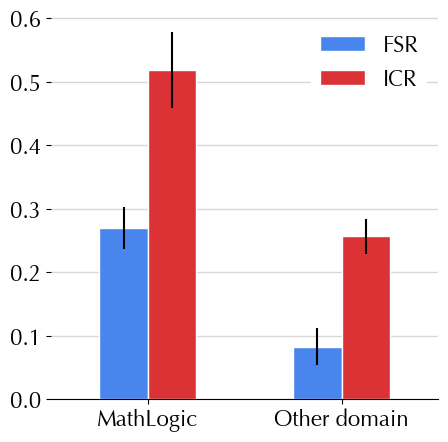

In [72]:
# compare rl and non-rl
model_pair_list = [["r1llama", "r1llama_rl"], ["r1qwen", "r1qwen_rl"]]
FSR_ratio_list = []
ICR_ratio_list = []
FSR_ratio_list_transfer = []
ICR_ratio_list_transfer = []
for model_pair in model_pair_list:
    for group in group_name_list:
        if group == "MathLogic":
            FSR_ratio_list.append(total_dic[model_pair[1]][group][0] / total_dic[model_pair[0]][group][0])
            ICR_ratio_list.append(total_dic[model_pair[1]][group][1] / total_dic[model_pair[0]][group][1])
        else:
            FSR_ratio_list_transfer.append(total_dic[model_pair[1]][group][0] / total_dic[model_pair[0]][group][0])
            ICR_ratio_list_transfer.append(total_dic[model_pair[1]][group][1] / total_dic[model_pair[0]][group][1])
FSR_ratio_list = np.array(FSR_ratio_list)
ICR_ratio_list = np.array(ICR_ratio_list)
FSR_ratio_list_transfer = np.array(FSR_ratio_list_transfer)
ICR_ratio_list_transfer = np.array(ICR_ratio_list_transfer)
width = 0.25
x = np.arange(2)
x1 = x - width/2
x2 = x + width/2
fig = Figure(name = 'ratio', figsize=(5, 5))
fig.bar(x1, [1 - np.mean(FSR_ratio_list), 1 - np.mean(FSR_ratio_list_transfer)], yerr = [np.std(FSR_ratio_list), np.std(FSR_ratio_list_transfer)], width = width, label='FSR', color = ting_color["blue_light"], align= 'center')
fig.bar(x2, [1 - np.mean(ICR_ratio_list), 1 - np.mean(ICR_ratio_list_transfer)], yerr = [np.std(ICR_ratio_list), np.std(ICR_ratio_list_transfer)], width = width, label='ICR', color = ting_color["red"], align= 'center')
fig.set_legend()

fig.set_axis_lim("x", piece = 1, lim = (0, 1), labels = ["MathLogic", "Other domain"], margin=(0.5,0.5))

# decrease ratio

# intermediate model in training